# BIVARIATE ANALYSIS

## Load the data
- Here I load the pickle file that was saved in step1

In [7]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# We load the pickle file so we have the correct data type

df = pd.read_pickle('data_MPG_clean.pkl')

In [9]:
# print 10 sample values

print(df.sample(10))

           mpg  cylinders  displacement  horsepower  weight  acceleration  \
202  17.500000          6           258          95    3193     17.796875   
337  32.406250          4           107          72    2290     17.000000   
155  15.000000          6           250          72    3158     19.500000   
197  29.000000          4            90          70    1937     14.203125   
148  26.000000          4           116          75    2246     14.000000   
60   20.000000          4           140          90    2408     19.500000   
262  19.203125          8           305         145    3425     13.203125   
234  24.500000          4           151          88    2740     16.000000   
315  24.296875          4           151          90    3003     20.093750   
69   12.000000          8           350         160    4456     13.500000   

     model_year  origin  
202          76     usa  
337          80   japan  
155          75     usa  
197          76  europe  
148          74  europ

In [10]:
# lets see data types and memory usage

print(df.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float16 
 1   cylinders     392 non-null    int8    
 2   displacement  392 non-null    int16   
 3   horsepower    392 non-null    int16   
 4   weight        392 non-null    int16   
 5   acceleration  392 non-null    float16 
 6   model_year    392 non-null    int8    
 7   origin        392 non-null    category
dtypes: category(1), float16(2), int16(3), int8(2)
memory usage: 8.2 KB
None


In [11]:
# Display the descriptive stats

print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  392.000000  392.000000    392.000000  392.000000   392.000000   
mean    23.453125    5.471939    194.410714  104.469388  2977.584184   
std      7.804688    1.705783    104.645191   38.491160   849.402560   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.000000    4.000000    105.000000   75.000000  2225.250000   
50%     22.750000    4.000000    151.000000   93.500000  2803.500000   
75%     29.000000    8.000000    275.750000  126.000000  3614.750000   
max     46.593750    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    392.000000  392.000000  
mean      15.539062   75.979592  
std        2.757812    3.683737  
min        8.000000   70.000000  
25%       13.773438   73.000000  
50%       15.500000   76.000000  
75%       17.023438   79.000000  
max       24.796875   82.000000  


# Numerical vs Numerical (Scatter Plot)

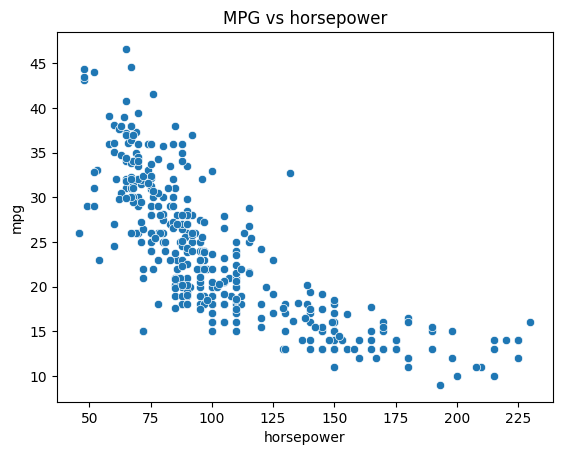

In [12]:
# step0: simple plot 

col = "horsepower"

sns.scatterplot(data=df, x=col, y='mpg')
plt.title(f'MPG vs {col}')
plt.show()

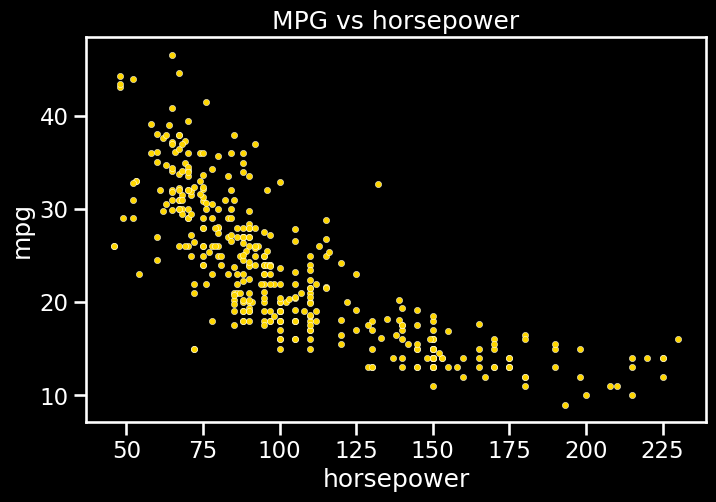

<Figure size 640x480 with 0 Axes>

In [13]:
# step1: prettify above

plt.style.use("dark_background")  
# Optional: control Seaborn palette and font scale
sns.set_palette(["gold"])
sns.set_context("talk")
plt.figure(figsize=(8,5))


col = "horsepower"

# sns.regplot(data=df, x='horsepower', y='mpg') # Regression line shows trend clearly.
sns.scatterplot(data=df, x=col, y='mpg', s=20)
plt.title(f'MPG vs {col}')
plt.show()

# Observ:
# Downward trend → negative correlation
# Higher horsepower → lower mpg

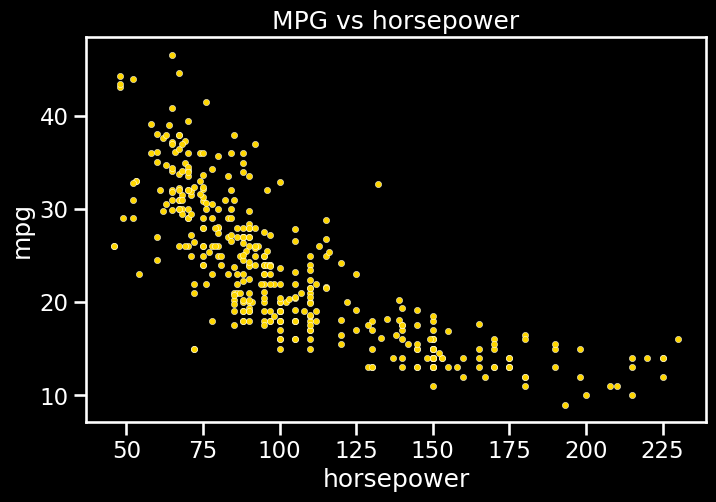

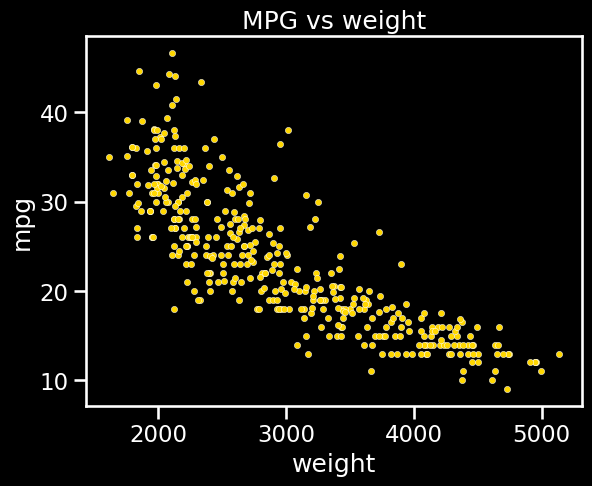

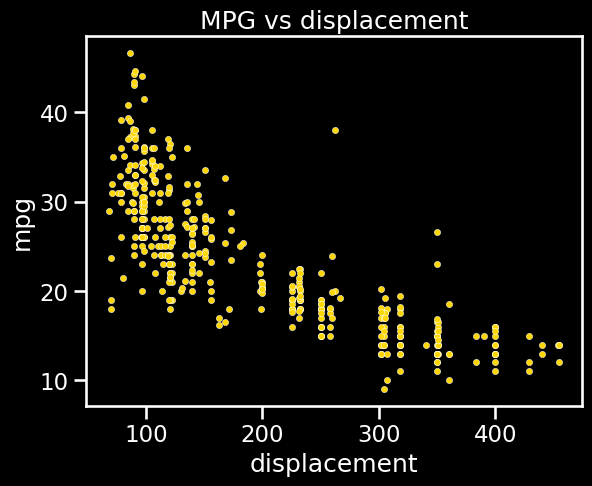

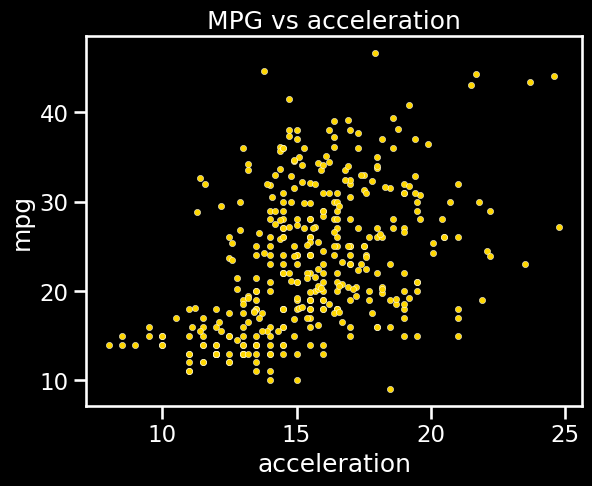

In [16]:
# step2: Use for loop
plt.style.use("dark_background")  
# Optional: control Seaborn palette and font scale
sns.set_palette(["gold"])
sns.set_context("talk")
plt.figure(figsize=(8,5))


columns = ["horsepower", "weight", "displacement", "acceleration"]

for col in columns:
    
    # sns.regplot(data=df, x='horsepower', y='mpg') # Regression line shows trend clearly.
    sns.scatterplot(data=df, x=col, y='mpg', s=20)
    plt.title(f'MPG vs {col}')
    plt.show()
    

# observ: As HP, weight, displacement increases, the MPG decrease.
# There appears almost no relation between acceleration and MPG

# Numerical vs Categorical

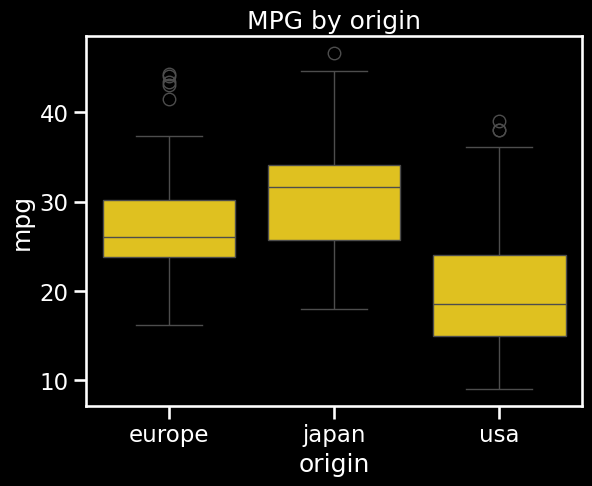

In [15]:
# step0:

col = "origin"

sns.boxplot(data=df, x=col, y='mpg')
plt.title(f'MPG by {col}')
plt.show()

# Japanese cars generally have higher mpg
# US cars have lower mpg on average

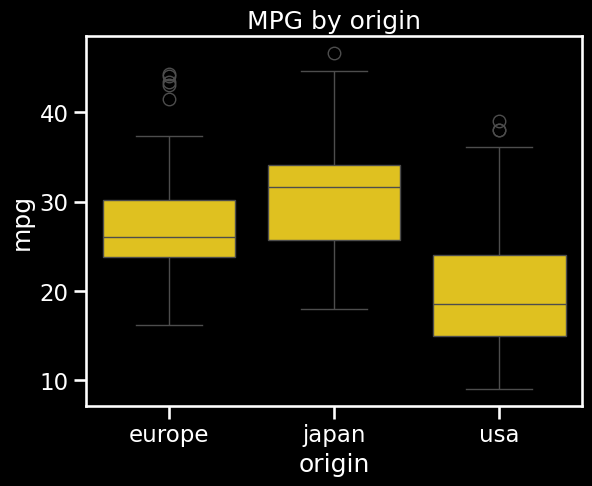

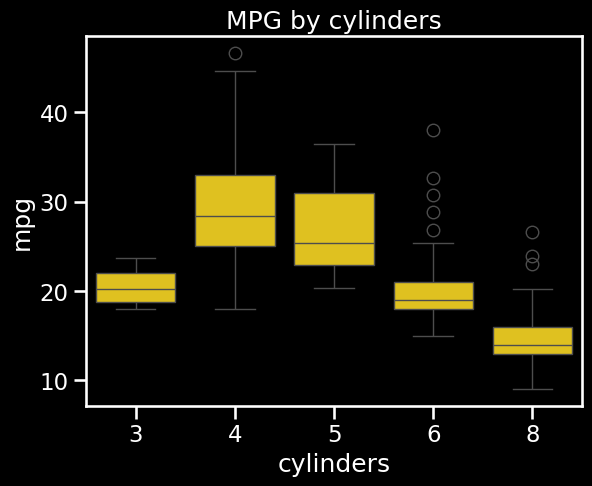

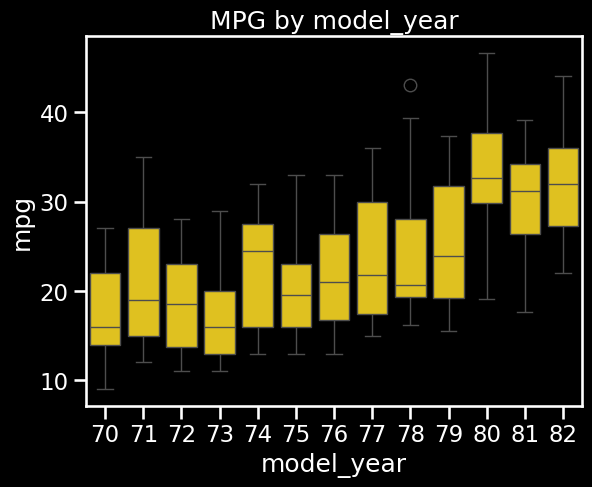

In [24]:
# step1: Now do MPG versus other columns

columns = ["origin", "cylinders", "model_year"]

for col in columns:
    sns.boxplot(data=df, x=col, y='mpg')
    plt.title(f'MPG by {col}')
    plt.show()

# Observ:
# MPG vs model_year: The mpg has gone up with years

# Use Violin Plot (Distribution + Density)

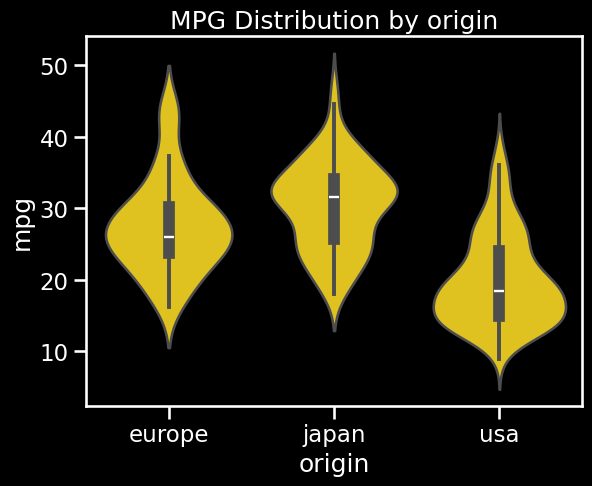

In [25]:

col = "origin"

sns.violinplot(data=df, x=col, y='mpg')
plt.title(f'MPG Distribution by {col}')
plt.show()

# Observ: Japan cars have better MPG

# Statistical Bivariate Insight (Correlation)

In [7]:
# step1: print numerical values

columns = ['mpg', 'horsepower', 'weight', 'acceleration']
corr_matrix = df[columns].corr()
print(corr_matrix)

                   mpg  horsepower    weight  acceleration
mpg           1.000000   -0.778430 -0.832237      0.423419
horsepower   -0.778430    1.000000  0.864538     -0.689212
weight       -0.832237    0.864538  1.000000     -0.416857
acceleration  0.423419   -0.689212 -0.416857      1.000000


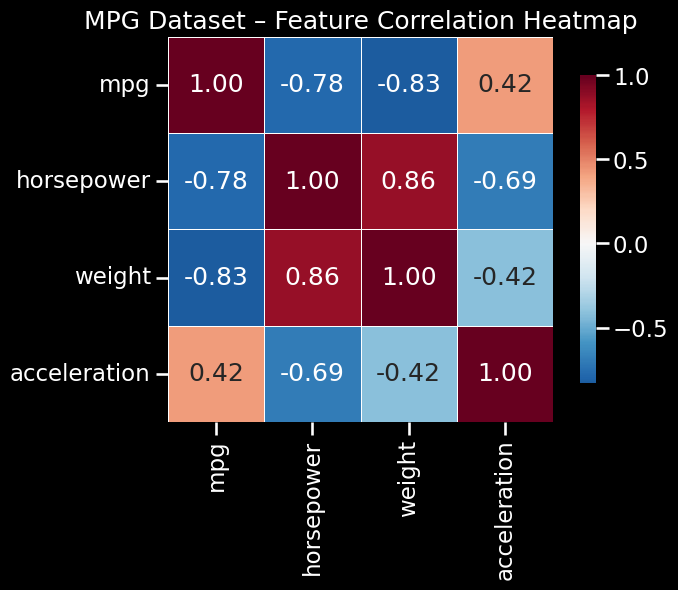

In [32]:
# step2: Now lets plot above using heatmap

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('MPG Dataset – Feature Correlation Heatmap')
plt.show()

In [ ]:
# Pairwise scatter plot

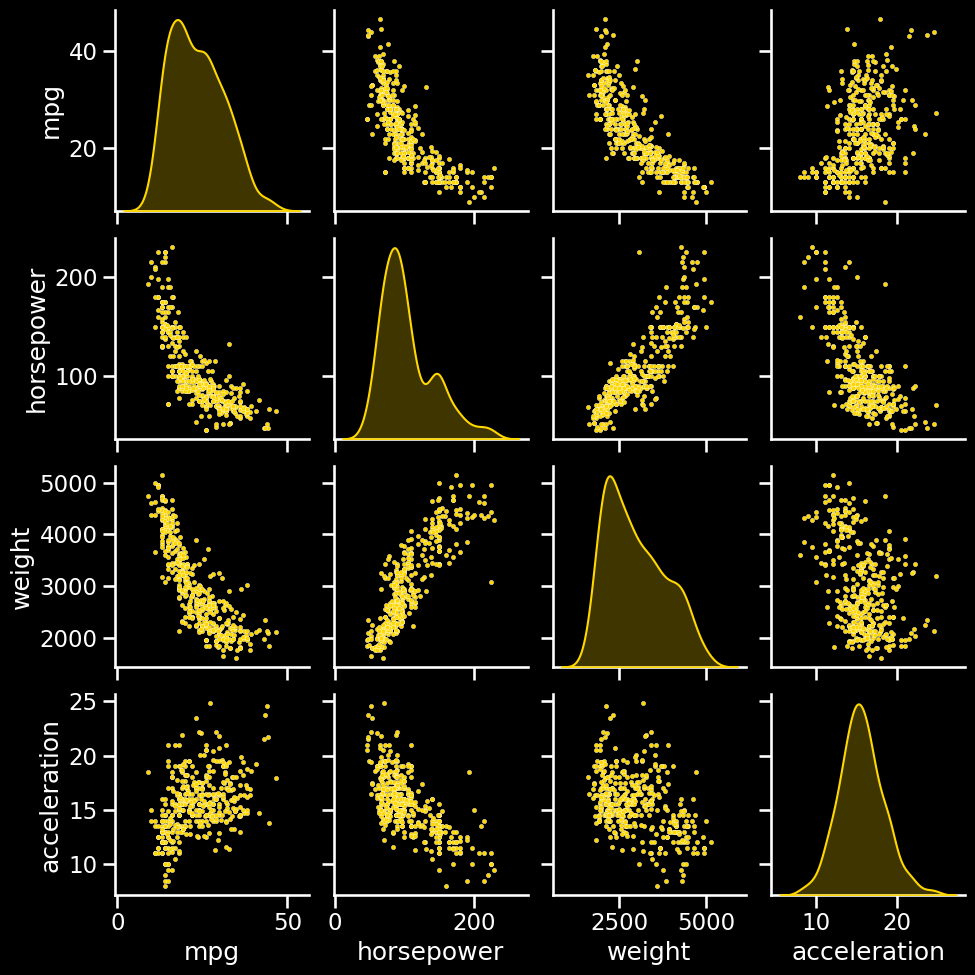

In [30]:

columns = ['mpg', 'horsepower', 'weight', 'acceleration']
sns.pairplot(
    df[columns],
    diag_kind='kde',
    plot_kws={'s': 10}   # marker size
)
plt.show()
